In [1]:
data = []

with open("train_bad.csv") as csv:
    while line := csv.readline():
        data.append(list(map(lambda x: x.strip(), line.split(";"))))

In [2]:
import numpy as np

In [3]:
xs, ys = [], []
graph_x, graph_y, colors = [], [], []

for x1, x2, name in data:
    xs.append([float(x1), float(x2)])
    ys.append(1.0 if name == "caterpillar" else -1.0)

    graph_x.append(int(x1))
    graph_y.append(int(x2))
    
    colors.append("red" if name == "caterpillar" else "blue")

x_train = np.array(xs, dtype="float")
y_train = np.array(ys, dtype="float")

In [4]:
from sklearn import svm

In [5]:
clf = svm.SVC(C=10, kernel="linear")
clf.fit(x_train, y_train)

# два последних определены неверно
print(clf.predict(x_train))

support_vectors = clf.support_vectors_

#support_x = []
#support_y = []

support_error_x, support_error_y = [], []
support_border_x, support_border_y = [], []

#for v in support_vectors:
    #support_x.append(int(v[0]))
    #support_y.append(int(v[1]))

for v, l in zip(support_vectors, np.abs(clf.dual_coef_[0])):
    if np.isclose(l, clf.C):
        support_error_x.append(int(v[0]))
        support_error_y.append(int(v[1]))
    elif 0 < l < clf.C:
        support_border_x.append(int(v[0]))
        support_border_y.append(int(v[1]))

w = clf.coef_[0]

# dual_coef_[0]_i = lambda_i * y_i
w, support_vectors[0], clf.intercept_[0]

[ 1. -1. -1.  1.  1. -1. -1.  1. -1.  1.  1. -1.]


(array([-0.09705575,  0.05046899]),
 array([20., 30.]),
 np.float64(-0.0872415828471655))

In [6]:
import matplotlib.pyplot as plt

x = np.linspace(0, 50, 2)

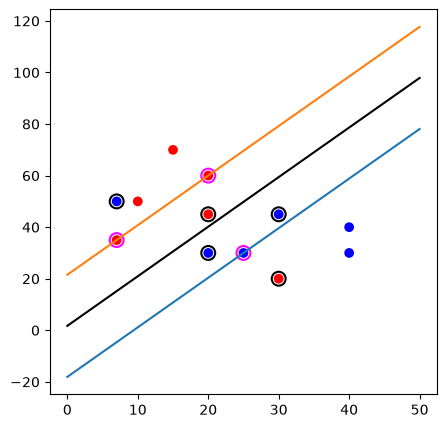

In [7]:
plt.figure(figsize=(5, 5))
plt.scatter(graph_x, graph_y, c=colors)
plt.scatter(support_border_x, support_border_y, facecolors="none", edgecolors="magenta", s=100, linewidths=1.5)
plt.scatter(support_error_x, support_error_y, facecolors="none", edgecolors="black", s=100, linewidths=1.5)

# w0 * x + w1 * y + b = 0 -> y = -(w0 * x + b) / w1
k = -w[0] / w[1]
y = k * x - clf.intercept_ / w[1]
plt.plot(x, y, "k")

plt.plot(x, k * (x - support_border_x[0]) + support_border_y[0])
plt.plot(x, k * (x - support_border_x[1]) + support_border_y[1])

In [8]:
samples = np.array([[20, 20], [30, 30], [40, 40], [10, 40]])

In [9]:
predictions = np.array([0.0] * len(samples))

for i, sample in enumerate(samples):
    predictions[i] = 1.0 if np.dot(w, sample) + clf.intercept_[0] > 0 else -1.0

predictions

array([-1., -1., -1.,  1.])

In [10]:
clf.predict(samples), clf.decision_function(samples)

(array([-1., -1., -1.,  1.]),
 array([-1.01897678, -1.48484438, -1.95071198,  0.96096052]))

In [ ]:
def model(sample):
    s = 0.0

    for sv, dc in zip(clf.support_vectors_, clf.dual_coef_[0]):
        s += dc * np.dot(sv, sample)

    return clf.classes_[int(s + clf.intercept_[0] > 0)]

def predict(samples):
    return np.array([model(s) for s in samples])

In [12]:
predict(samples)

array([-1., -1., -1.,  1.])